In [1]:
!pip install -q keras-nlp matplotlib

In [2]:
import pandas as pd
import keras_nlp
import tensorflow as tf
import matplotlib.pyplot as plt
import random

In [3]:
from pathlib import Path

# List of dataset file names
file_names = [
    "CancerQA.csv",
    "Diabetes_and_Digestive_and_Kidney_DiseasesQA.csv",
    "Disease_Control_and_PreventionQA.csv",
    "Genetic_and_Rare_DiseasesQA.csv",
    "Heart_Lung_and_BloodQA.csv",
    "Neurological_Disorders_and_StrokeQA.csv",
    "OtherQA.csv",
    "SeniorHealthQA.csv",
    "growth_hormone_receptorQA.csv"
]

# Load and combine datasets
dataframes = []
for file in file_names:
    path = Path(f"/kaggle/input/cancer-q-and-a-dataset/{file}")
    if path.exists():
        df = pd.read_csv(path)
        dataframes.append(df)

# Combine all dataframes
combined_df = pd.concat(dataframes, ignore_index=True)


In [4]:
# Step 4: Format into prompts
combined_df["text"] = combined_df.apply(
    lambda row: f"Patient: {row['Question']}\nDoctor: {row['Answer']}", axis=1
)

In [5]:
# Step 5: Split by 'split' column
train_texts = combined_df[combined_df["split"].str.lower() == "train"]["text"].tolist()
test_texts = combined_df[combined_df["split"].str.lower() == "test"]["text"].tolist()

In [6]:
# Step 6: Leave raw text, do NOT tokenize yet
train_ds = tf.data.Dataset.from_tensor_slices(train_texts).batch(2)
val_ds = tf.data.Dataset.from_tensor_slices(test_texts).batch(2)

In [7]:
gpt2_lm = keras_nlp.models.GPT2CausalLM.from_preset("gpt2_base_en")

# Compile model for language modeling
gpt2_lm.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5))


In [8]:
history = gpt2_lm.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
6561/6561 ━━━━━━━━━━━━━━━━━━━━ 4592s 689ms/step - loss: 0.5686 - sparse_categorical_accuracy: 0.6683 - val_loss: 0.4540 - val_sparse_categorical_accuracy: 0.6485
Epoch 2/5
6561/6561 ━━━━━━━━━━━━━━━━━━━━ 4515s 688ms/step - loss: 0.4615 - sparse_categorical_accuracy: 0.7136 - val_loss: 0.4017 - val_sparse_categorical_accuracy: 0.6827
Epoch 3/5
6561/6561 ━━━━━━━━━━━━━━━━━━━━ 4517s 688ms/step - loss: 0.4044 - sparse_categorical_accuracy: 0.7389 - val_loss: 0.3831 - val_sparse_categorical_accuracy: 0.6974
Epoch 4/5
6561/6561 ━━━━━━━━━━━━━━━━━━━━ 4519s 689ms/step - loss: 0.3669 - sparse_categorical_accuracy: 0.7568 - val_loss: 0.3765 - val_sparse_categorical_accuracy: 0.7038
Epoch 5/5
6561/6561 ━━━━━━━━━━━━━━━━━━━━ 4519s 689ms/step - loss: 0.3378 - sparse_categorical_accuracy: 0.7707 - val_loss: 0.3750 - val_sparse_categorical_accuracy: 0.7080


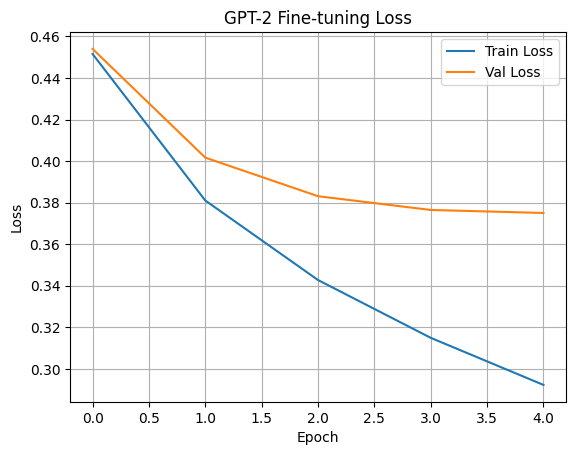

In [9]:
# Save fine-tuned model
gpt2_lm.save("/kaggle/working/fine_tuned_gpt2_qa.keras")

# Plot training loss
plt.plot(history.history["loss"], label="Train Loss")
if "val_loss" in history.history:
    plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("GPT-2 Fine-tuning Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig("training_loss_plot.png")
plt.show()